In [42]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
np.random.seed(2025)   

# ---------------------------
# Helper functions
# ---------------------------

def compute_epsilon(states, alpha, epsilon0):
    p_A = states[:, 1] + states[:, 2] + states[:, 4]
    return np.where(p_A > alpha, epsilon0, 0.0)

def compute_effective_awareness(n, states, g_i, R):
    N, M = len(n), R.shape[1]
    p_A = states[:,1] + states[:,2] + states[:,4]
    tilde_p = np.zeros(M)
    for j in range(M):
        flows = n * g_i * R[:, j]
        total_flow = flows.sum()
        tilde_p[j] = (flows * p_A).sum() / total_flow if total_flow > 0 else 0.0
    return tilde_p

def compute_awareness_conversion(R, lambda1, tilde_p):
    N, M = R.shape
    r = np.zeros(N)
    for i in range(N):
        prod = 1.0
        for j in range(M):
            prod *= (1 - lambda1 * R[i, j] * tilde_p[j])
        r[i] = 1 - prod
    return r

def compute_infection_residence(n, states, g_i, beta_U, beta_A):
    n_remain = n * (1 - g_i)
    p_I = states[:, 2]
    N_U = 1 - (1 - beta_U * p_I) ** n_remain
    N_A = 1 - (1 - beta_A * p_I) ** n_remain
    return N_U, N_A

def compute_infection_transit(n, states, g_i, R, beta_U, beta_A):
    N, M = R.shape
    M_U = np.zeros(M)
    M_A = np.zeros(M)
    p_I = states[:, 2]
    for j in range(M):
        prod_U, prod_A = 1.0, 1.0
        for i in range(N):
            flow = n[i] * g_i[i] * R[i, j]
            prod_U *= (1 - beta_U * p_I[i]) ** flow
            prod_A *= (1 - beta_A * p_I[i]) ** flow
        M_U[j] = 1 - prod_U
        M_A[j] = 1 - prod_A
    return M_U, M_A

def compute_overall_infection(n, states, g_i, R, N_U, N_A, M_U, M_A):
    N = len(n)
    Q_U = np.zeros(N)
    Q_A = np.zeros(N)
    for i in range(N):
        Q_U[i] = (1 - g_i[i]) * N_U[i] + g_i[i] * np.dot(R[i], M_U)
        Q_A[i] = (1 - g_i[i]) * N_A[i] + g_i[i] * np.dot(R[i], M_A)
    return Q_U, Q_A

def update_states(states, r, Q_U, Q_A, mu1, mu2):
    US, AS, AI, UR, AR = [states[:, k] for k in range(5)]
    new = np.zeros_like(states)
    new[:, 0] = US*(1-r)*(1-Q_U) + AS*mu1*(1-Q_U)
    new[:, 1] = AS*(1-mu1)*(1-Q_A) + US*r*(1-Q_A)
    new[:, 2] = AI*(1-mu2) + AS*(1-mu1)*Q_A + AS*mu1*Q_U + US*(1-r)*Q_U + US*r*Q_A
    new[:, 3] = AI*mu1*mu2 + AR*mu1 + UR*(1-r)
    new[:, 4] = AR*(1-mu1) + AI*(1-mu1)*mu2 + UR*r
    return new / np.clip(new.sum(axis=1, keepdims=True), 1e-10, None)

def update_population(n, states, g_i, epsilon, R, T):
    X = states * n[:, None]
    F = n * g_i * epsilon
    X_remain = X - (X.T * (g_i * epsilon)).T
    n_remain = n - F

    M = R.shape[1]
    m = np.zeros(M); m_X = np.zeros((M,5))
    for j in range(M):
        flows = n * g_i * epsilon * R[:, j]
        m[j] = flows.sum()
        m_X[j] = (X * (g_i * epsilon)[:, None] * R[:, j][:, None]).sum(axis=0)

    flow_return = np.zeros_like(n, dtype=float)
    flow_return_X = np.zeros_like(X, dtype=float)
    for j in range(M):
        flow_return += m[j] * T[:, j]
        flow_return_X += np.outer(T[:, j], m_X[j])

    n_new = n_remain + flow_return
    X_new = X_remain + flow_return_X
    new_states = X_new / np.clip(n_new[:, None], 1e-10, None)
    return n_new, new_states

# ---------------------------
# Main simulation function
# ---------------------------
def main_simulation(Time, N, M, params):
    lambda1, mu1, mu2 = params['lambda1'], params['mu1'], params['mu2']
    beta_U, beta_A    = params['beta_U'], params['beta_A']
    g, theta          = params['g'], params['theta']
    epsilon0, alpha   = params['epsilon0'], params['alpha']

    g_i = np.full(N, theta * g)
    n = np.arange(100, 100 + 50 * N, 50, dtype=int)
    states = np.zeros((N,5)); states[:,0]=0.99; states[:,2]=0.01
    states /= states.sum(axis=1, keepdims=True)

    w = np.random.rand(N, M)
    R = w / w.sum(axis=1, keepdims=True)
    T = w / w.sum(axis=0, keepdims=True)

    state_hist = np.zeros((Time, N, 5))
    pop_hist   = np.zeros((Time, N))

    for t in range(Time):
        state_hist[t] = states.copy()
        pop_hist[t]   = n.copy()

        epsilon = compute_epsilon(states, alpha, epsilon0)
        n, states = update_population(n, states, g_i, epsilon, R, T)

        tilde_p = compute_effective_awareness(n, states, g_i, R)
        r       = compute_awareness_conversion(R, lambda1, tilde_p)

        N_U, N_A = compute_infection_residence(n, states, g_i, beta_U, beta_A)
        M_U, M_A = compute_infection_transit(n, states, g_i, R, beta_U, beta_A)
        Q_U, Q_A = compute_overall_infection(n, states, g_i, R, N_U, N_A, M_U, M_A)

        states = update_states(states, r, Q_U, Q_A, mu1, mu2)

    return state_hist, pop_hist



In [43]:
# ---------------------------
# Experiment: Peak AI vs ε₀ for different α
# ---------------------------
Time, N, M = 140, 15, 5
epsilon_list = np.arange(0.1, 0.5, 0.05)
alpha_list   = [0.2, 0.5, 0.8]
num_sims     = 50

base_params = {
    'lambda1': 0.05,
    'mu1':     0.15,
    'mu2':     0.2,
    'beta_U':  0.003,
    'beta_A':  0.0015,
    'g':       0.5,
    'theta':   1
}

mean_peak = {alpha: [] for alpha in alpha_list}


for alpha in alpha_list:
    for eps in tqdm(epsilon_list, desc=f"α={alpha}"):
        peaks = []
        for _ in range(num_sims):
            params = base_params.copy()
            params.update({'alpha': alpha, 'epsilon0': eps})
            hist, pop_hist = main_simulation(Time, N, M, params)
            ai_t = [
                np.sum(hist[t] * pop_hist[t][:, None], axis=0)[2] / np.sum(pop_hist[t])
                for t in range(Time)
            ]
            peaks.append(max(ai_t))
        mean_peak[alpha].append(np.mean(peaks))



α=0.8: 100%|██████████| 8/8 [00:13<00:00,  1.67s/it]


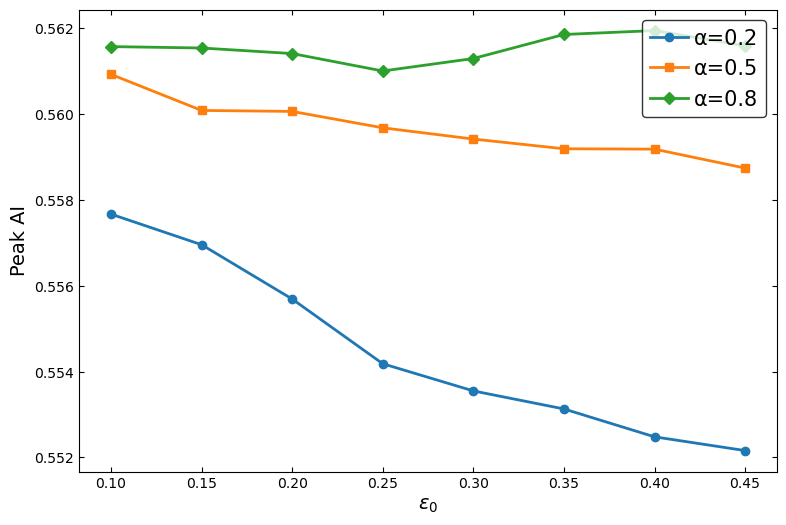

In [44]:
# Plotting
plt.figure(figsize=(9, 6))
markers = ['o', 's', 'D', '^']
for alpha, marker in zip(alpha_list, markers):
    plt.errorbar(
        epsilon_list, mean_peak[alpha], 
        label=f'α={alpha}', marker=marker, linewidth=2
    )

legend = plt.legend(
    loc='upper right',
    fontsize='15',
    handletextpad=0.3,    # 图标与文本的间距
    borderpad=0.4,          # 图例内边距
    handlelength=1.8,    # 统一图标宽度
)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)
    
# 启用四面刻度
plt.tick_params(
    axis='both',      # 同时控制 x 和 y 轴
    which='both',     # 同时控制主刻度和次刻度
    top=True,         # 显示顶部刻度
    right=True,       # 显示右侧刻度
    labeltop=False,   # 不显示顶部刻度标签（避免重叠）
    labelright=False,  # 不显示右侧刻度标签（避免重叠）
    direction='in',   # 刻度朝内
)

plt.xlabel(r'$\epsilon_0$', fontsize=14)
plt.ylabel('Peak AI', fontsize=14)


plt.show()
